In [1]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import sys
# import os
# sys.path.insert(0, os.path.abspath('..'))
# from src.eda import dataset_overview, missing_values_report, check_duplicates, get_numerical_columns, skewness_report,plot_histograms,categorical_distribution,plot_categorical_distribution,correlation_heatmap,plot_boxplots,outlier_report
# # Set plot style
# sns.set_style("whitegrid")

In [2]:
import pandas as pd
import numpy as np
import sys
import os

sys.path.append(
    os.path.abspath("..")
)
from src.edaf.analyzer import FraudEDA
from src.edaf.visualizer import EDAVisualizer

# EDA
## Import Data

In [3]:
df = pd.read_csv("../data/raw/data.csv")

In [4]:
eda = FraudEDA(df)

viz = EDAVisualizer(df)

## Data Overview
### Dataset Shape

In [5]:
eda.dataset_overview()

{'rows': 95662, 'columns': 16}

### Data Types

In [6]:
eda.data_types()

,dtype
TransactionId,object
BatchId,object
AccountId,object
SubscriptionId,object
CustomerId,object
CurrencyCode,object
CountryCode,int64
ProviderId,object
ProductId,object
ProductCategory,object


### Missing Values Analysis

In [7]:
eda.missing_values()

,Missing Count,Missing Percentage
TransactionId,0,0.0
BatchId,0,0.0
AccountId,0,0.0
SubscriptionId,0,0.0
CustomerId,0,0.0
CurrencyCode,0,0.0
CountryCode,0,0.0
ProviderId,0,0.0
ProductId,0,0.0
ProductCategory,0,0.0


### Duplicate Records

In [8]:
eda.duplicate_count()

np.int64(0)

## Summary Statistics

### Numerical Summary

In [9]:
eda.summary_statistics()

,count,mean,std,min,25%,50%,75%,max
CountryCode,95662.0,256.000000,0.000000,256.0,256.0,256.0,256.0,256.0
Amount,95662.0,6717.846433,123306.797164,-1000000.0,-50.0,1000.0,2800.0,9880000.0
Value,95662.0,9900.583941,123122.087776,2.0,275.0,1000.0,5000.0,9880000.0
PricingStrategy,95662.0,2.255974,0.732924,0.0,2.0,2.0,2.0,4.0
FraudResult,95662.0,0.002018,0.044872,0.0,0.0,0.0,0.0,1.0


### Skewness

In [10]:
eda.skewness_report()

Value              51.291086
Amount             51.098490
FraudResult        22.196295
PricingStrategy     1.659057
CountryCode         0.000000
dtype: float64

## Distribution of Numerical Features

In [11]:
numerical_cols = [
    "Amount",
    "Value"
]

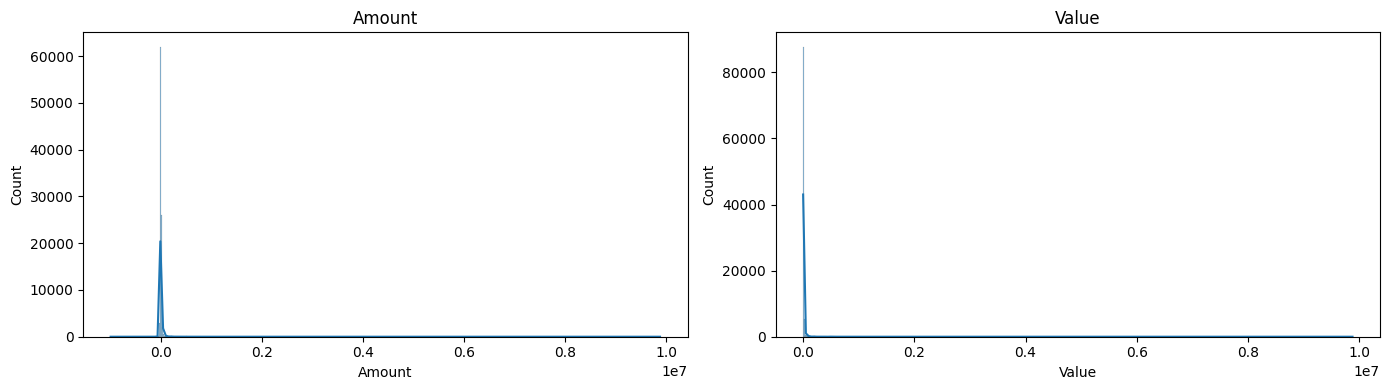

In [12]:
viz.numerical_distributions(
    numerical_cols
)

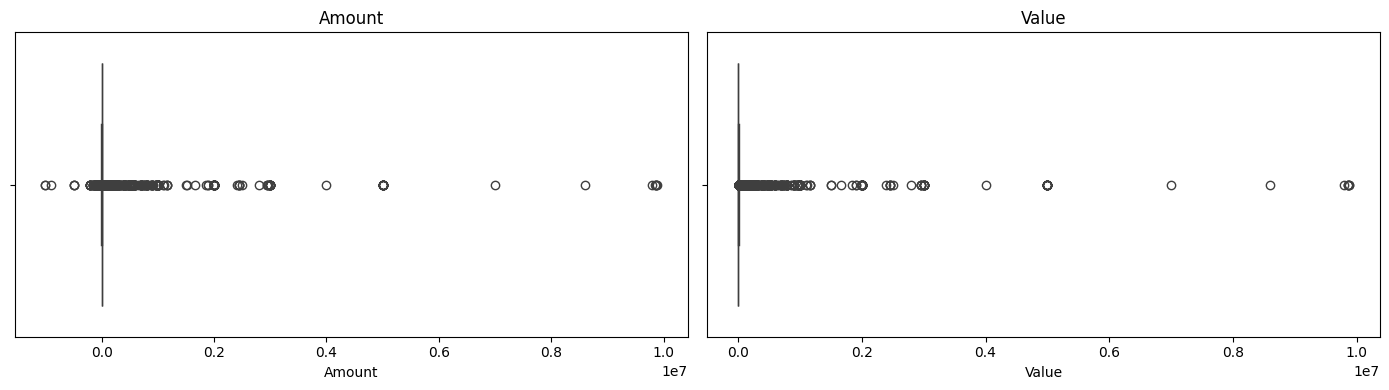

In [13]:
viz.boxplots(
    numerical_cols
)

## Distribution of Categorical Features

In [14]:
categorical_cols = [
    "ProductCategory",
    "ChannelId",
    "ProviderId",
    "PricingStrategy"
]

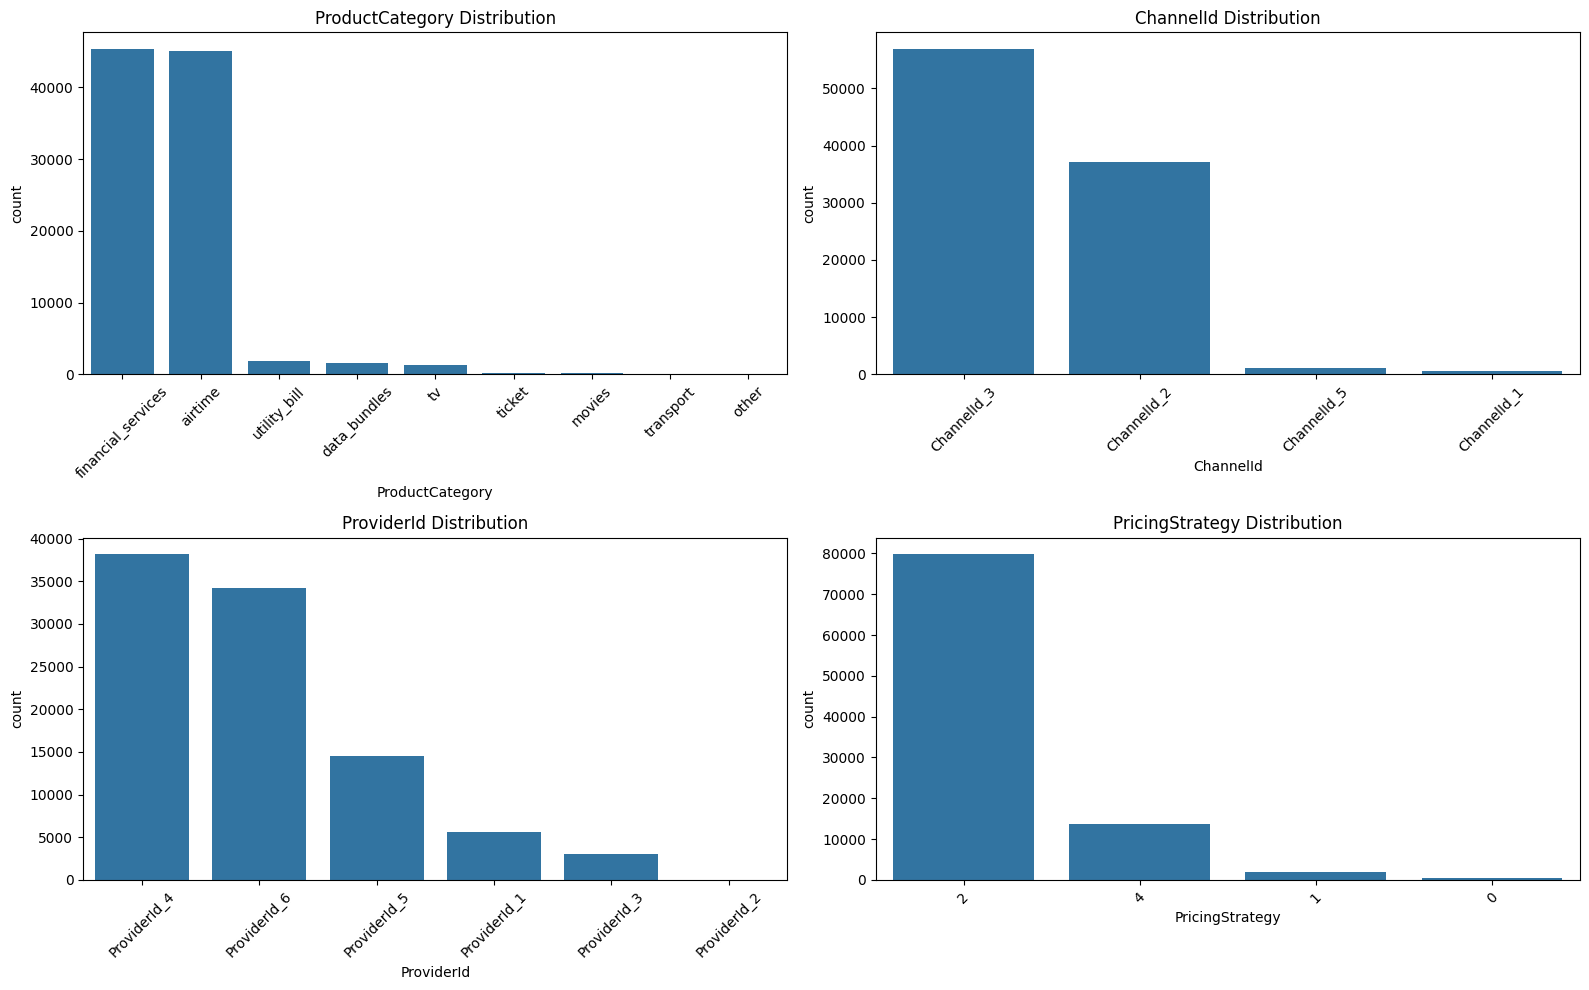

In [15]:
viz.categorical_distributions()

### Product Category

In [16]:
eda.categorical_distribution(
    "ProductCategory"
)



ProductCategory
financial_services    45405
airtime               45027
utility_bill           1920
data_bundles           1613
tv                     1279
ticket                  216
movies                  175
transport                25
other                     2
Name: count, dtype: int64

### Channel

In [17]:
eda.categorical_distribution(
    "ChannelId"
)



ChannelId
ChannelId_3    56935
ChannelId_2    37141
ChannelId_5     1048
ChannelId_1      538
Name: count, dtype: int64

### Provider

In [18]:
eda.categorical_distribution(
    "ProviderId"
)

ProviderId
ProviderId_4    38189
ProviderId_6    34186
ProviderId_5    14542
ProviderId_1     5643
ProviderId_3     3084
ProviderId_2       18
Name: count, dtype: int64

In [19]:
eda.categorical_distribution(
    "PricingStrategy"
)

PricingStrategy
2    79848
4    13562
1     1867
0      385
Name: count, dtype: int64

### Fraud Result

In [20]:
eda.fraud_distribution()



,Count,Percentage
FraudResult,,
0,95469,99.8
1,193,0.2


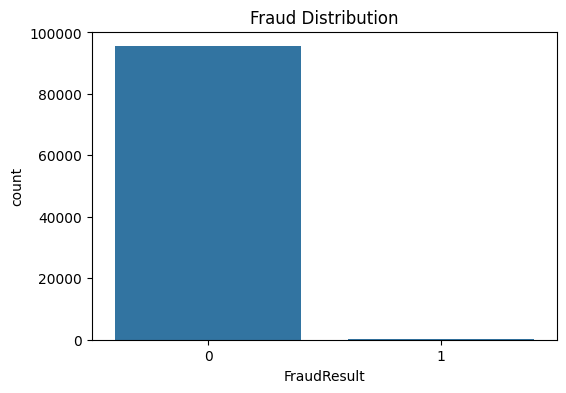

In [21]:
viz.fraud_distribution()

In [22]:
corr = numerical_cols = [
    "Amount",
    "Value",
    "PricingStrategy",
    "FraudResult"
]
eda.correlation_matrix(corr)

,Amount,Value,PricingStrategy,FraudResult
Amount,1.000000,0.989692,-0.061931,0.557370
Value,0.989692,1.000000,-0.017020,0.566739
PricingStrategy,-0.061931,-0.017020,1.000000,-0.033821
FraudResult,0.557370,0.566739,-0.033821,1.000000


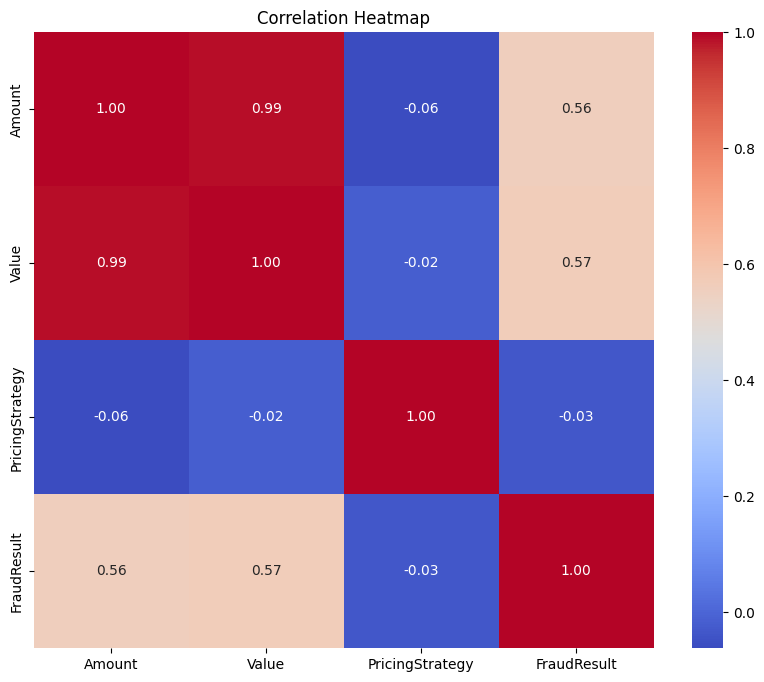

In [23]:
viz.correlation_heatmap(corr)

In [24]:
eda.outlier_report()

,Outlier Count,Outlier Percentage
Amount,24441.0,25.55
Value,9021.0,9.43
